<a href="https://colab.research.google.com/github/lucasvazelle/nexialog_challlenge/blob/main/etape4_model_ML_DBSCAN_PEAG_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
! pip install ace-tools

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from scipy.stats import genpareto


In [5]:
# chemin
file_path = "/content/drive/MyDrive/nexialog/data_aggrege_PEAG.parquet"

# Lire le fichier Parquet
data_agrege_S3 = pd.read_parquet(file_path)

In [6]:
data_agrege_S3.columns

Index(['peag_nro', 'date_hour', 'code_departement', 'olt_model', 'olt_name',
       'boucle', 'dsp', 'pop_dns', 'nb_test_dns', 'avg_dns_time',
       'std_dns_time', 'nb_test_scoring', 'avg_latence_scoring',
       'std_latence_scoring', 'avg_score_scoring', 'std_score_scoring',
       'nb_client_total', 'moment_journee', 'depts_egaux', 'meme_region',
       'missing_avg_dns_time', 'missing_std_dns_time',
       'missing_avg_latence_scoring', 'missing_std_latence_scoring',
       'missing_avg_score_scoring', 'missing_std_score_scoring', 'type_boucle',
       'type_olt_model', 'encodage_heure_sin', 'encodage_heure_cos',
       'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end'],
      dtype='object')

In [7]:
data_agrege_S3.head()

,peag_nro,date_hour,code_departement,olt_model,olt_name,boucle,dsp,pop_dns,nb_test_dns,avg_dns_time,...,missing_std_latence_scoring,missing_avg_score_scoring,missing_std_score_scoring,type_boucle,type_olt_model,encodage_heure_sin,encodage_heure_cos,encodage_jour_semaine_sin,encodage_jour_semaine_cos,week_end
0,01_peag_1,2024-12-01 00:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,61,4.888439,...,0,0,0,BU,old,0.000000,1.000000,-0.781831,0.62349,True
1,01_peag_1,2024-12-01 01:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,58,5.293034,...,0,0,0,BU,old,0.258819,0.965926,-0.781831,0.62349,True
2,01_peag_1,2024-12-01 02:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,67,5.103739,...,0,0,0,BU,old,0.500000,0.866025,-0.781831,0.62349,True
3,01_peag_1,2024-12-01 03:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,40,5.342719,...,0,0,0,BU,old,0.707107,0.707107,-0.781831,0.62349,True
4,01_peag_1,2024-12-01 04:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,50,4.997415,...,0,0,0,BU,old,0.866025,0.500000,-0.781831,0.62349,True


In [8]:
data_agrege_S3.isna().sum()

,0
peag_nro,0
date_hour,0
code_departement,0
olt_model,0
olt_name,0
boucle,0
dsp,0
pop_dns,0
nb_test_dns,0
avg_dns_time,2701


## DBSCAN

paramètre eps définit la distance maximale entre deux points pour qu'ils soient considérés comme voisins, et min_samples définit le nombre minimum de voisins requis pour qu'un point soit considéré comme faisant partie d'un cluster

### pour les tests scoring le meilleur epsilon est de 3 (detection des pics)

### fonctions

In [9]:
def detect_anomalies_dbscan(df, test_type='dns', eps=3, min_samples=4):
    """
    Détecte les anomalies avec DBSCAN

    Args:
        df: DataFrame avec les données
        test_type: 'dns', 'scoring' ou 'latence'
        eps: Paramètre eps pour DBSCAN
        min_samples: Paramètre min_samples pour DBSCAN

    Returns:
        DataFrame avec les prédictions d'anomalies
    """

    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Ajouter les caractéristiques temporelles
    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    # Combiner les features
    features = required_cols + time_features

    existing_features = [col for col in features if col in df.columns]

    # Nettoyer les données
    df_clean = df[existing_features + ['date_hour']].dropna().copy()

    if df_clean.empty:
        return None

    # Standardiser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[existing_features])

    # Appliquer DBSCAN
    model = DBSCAN(eps=eps, min_samples=min_samples)
    df_clean[prefix] = model.fit_predict(X_scaled)

    return df_clean

Nombre total de points DNS: 1488
Nombre d'anomalies DNS: 10 (0.67%)


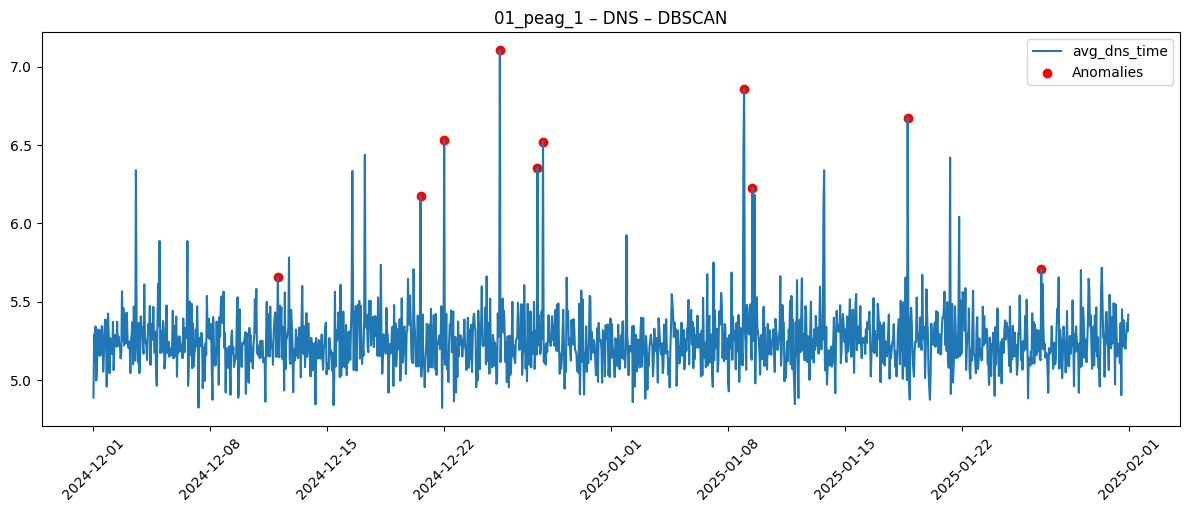

Nombre total de points Latence: 1488
Nombre d'anomalies Latence: 18 (1.21%)


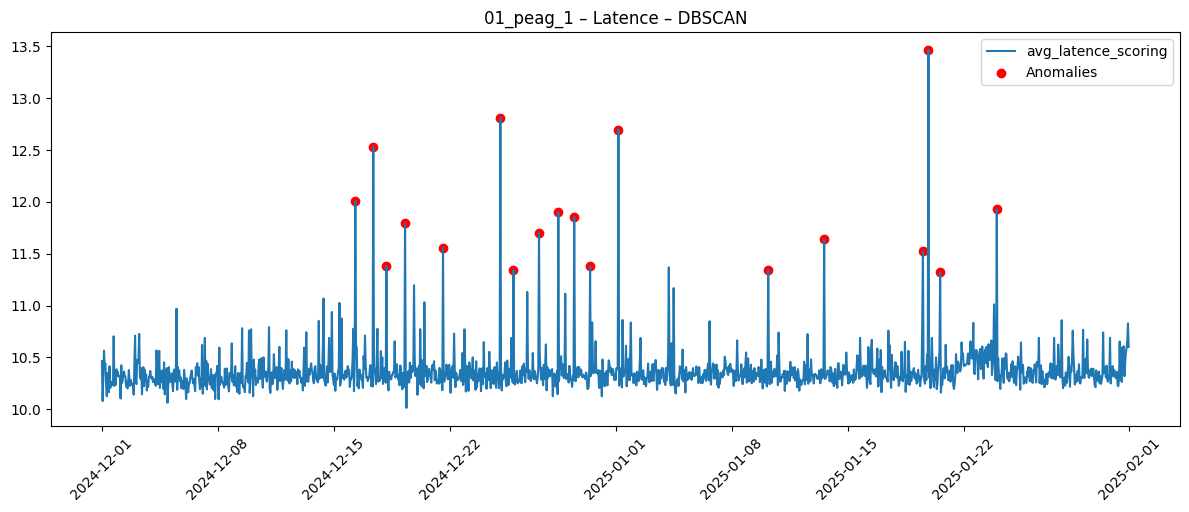

In [10]:
# Choisir un PEAG
peag_test = "01_peag_1"  # Remplacez par un de vos PEAGs
df_peag = data_agrege_S3[data_agrege_S3['peag_nro'] == peag_test]

# Appliquer DBSCAN pour le DNS
df_anomalies_dns = detect_anomalies_dbscan(df_peag, test_type='dns', eps=3, min_samples=8)

# Vérifier les résultats DNS
if df_anomalies_dns is not None:
    # Compter les anomalies
    anomaly_col = 'anomaly_dns'
    anomaly_count = sum(df_anomalies_dns[anomaly_col] == -1)
    print(f"Nombre total de points DNS: {len(df_anomalies_dns)}")
    print(f"Nombre d'anomalies DNS: {anomaly_count} ({anomaly_count/len(df_anomalies_dns)*100:.2f}%)")

    # Visualiser
    plt.figure(figsize=(12, 5))
    plt.plot(df_anomalies_dns['date_hour'], df_anomalies_dns['avg_dns_time'], label='avg_dns_time')
    plt.scatter(
        df_anomalies_dns['date_hour'][df_anomalies_dns[anomaly_col] == -1],
        df_anomalies_dns['avg_dns_time'][df_anomalies_dns[anomaly_col] == -1],
        color='red', label='Anomalies'
    )
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.title(f"{peag_test} – DNS – DBSCAN")
    plt.show()
else:
    print("Aucune donnée DNS exploitable")

# Appliquer DBSCAN pour la Latence
df_anomalies_latence = detect_anomalies_dbscan(df_peag, test_type='latence', eps=3, min_samples=8)

# Vérifier les résultats Latence
if df_anomalies_latence is not None:
    # Compter les anomalies
    anomaly_col = 'anomaly_latence'
    anomaly_count = sum(df_anomalies_latence[anomaly_col] == -1)
    print(f"Nombre total de points Latence: {len(df_anomalies_latence)}")
    print(f"Nombre d'anomalies Latence: {anomaly_count} ({anomaly_count/len(df_anomalies_latence)*100:.2f}%)")

    # Visualiser
    plt.figure(figsize=(12, 5))
    plt.plot(df_anomalies_latence['date_hour'], df_anomalies_latence['avg_latence_scoring'], label='avg_latence_scoring')
    plt.scatter(
        df_anomalies_latence['date_hour'][df_anomalies_latence[anomaly_col] == -1],
        df_anomalies_latence['avg_latence_scoring'][df_anomalies_latence[anomaly_col] == -1],
        color='red', label='Anomalies'
    )
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.title(f"{peag_test} – Latence – DBSCAN")
    plt.show()
else:
    print("Aucune donnée Latence exploitable")

In [11]:
def add_dbscan_anomaly_columns(df, test_types=['dns', 'scoring', 'latence']):
    """
    Ajoute des colonnes indiquant si chaque point est une anomalie selon DBSCAN

    Args:
        df: DataFrame complet
        test_types: Types de tests à analyser

    Returns:
        DataFrame avec colonnes d'anomalies ajoutées
    """
    df_result = df.copy()

    # Créer les colonnes d'anomalies au début avec False par défaut
    for test_type in test_types:
        flag_col = f'is_anomaly_{test_type}'
        df_result[flag_col] = False

    # Pour chaque PEAG
    for peag in df['peag_nro'].unique():
        print(f"Traitement de l'OLT: {peag}")
        df_peag = df[df['peag_nro'] == peag]

        for test_type in test_types:
            print(f"  Type de test: {test_type}")
            flag_col = f'is_anomaly_{test_type}'

            # Appliquer DBSCAN
            df_anomalies = detect_anomalies_dbscan(df_peag, test_type=test_type)

            if df_anomalies is not None:
                if test_type == 'dns':
                    anomaly_col = 'anomaly_dns'
                elif test_type == 'scoring':
                    anomaly_col = 'anomaly_scoring'
                elif test_type == 'latence':
                    anomaly_col = 'anomaly_latence'
                else:
                    continue

                # Identifier les dates/heures des anomalies
                anomaly_dates = df_anomalies.loc[df_anomalies[anomaly_col] == -1, 'date_hour'].tolist()

                # Marquer les anomalies dans le DataFrame résultat
                mask = (df_result['peag_nro'] == peag) & (df_result['date_hour'].isin(anomaly_dates))
                df_result.loc[mask, flag_col] = True

                anomaly_count = len(anomaly_dates)
                print(f"    Anomalies: {anomaly_count} ({anomaly_count/len(df_anomalies)*100:.2f}%)")
            else:
                print(f"    Pas de données exploitables pour {test_type}")

    return df_result

In [12]:
# Appliquer à un sous-ensemble pour tester
peags_test = ["95_peag_5606", "01_peag_29", "01_peag_45"]
df_test = data_agrege_S3[data_agrege_S3['peag_nro'].isin(peags_test)]

# Ajouter les colonnes d'anomalies
df_with_anomalies = add_dbscan_anomaly_columns(df_test, test_types=['dns', 'scoring', 'latence'])

print("\nRésultats:")
print(f"Nombre d'anomalies DNS: {df_with_anomalies['is_anomaly_dns'].sum()}")
print(f"Nombre d'anomalies Scoring: {df_with_anomalies['is_anomaly_scoring'].sum()}")
print(f"Nombre d'anomalies Latence: {df_with_anomalies['is_anomaly_latence'].sum()}")

Traitement de l'OLT: 01_peag_29
  Type de test: dns
    Anomalies: 7 (1.24%)
  Type de test: scoring
    Anomalies: 1 (0.27%)
  Type de test: latence
    Anomalies: 8 (2.13%)

Résultats:
Nombre d'anomalies DNS: 7
Nombre d'anomalies Scoring: 1
Nombre d'anomalies Latence: 8


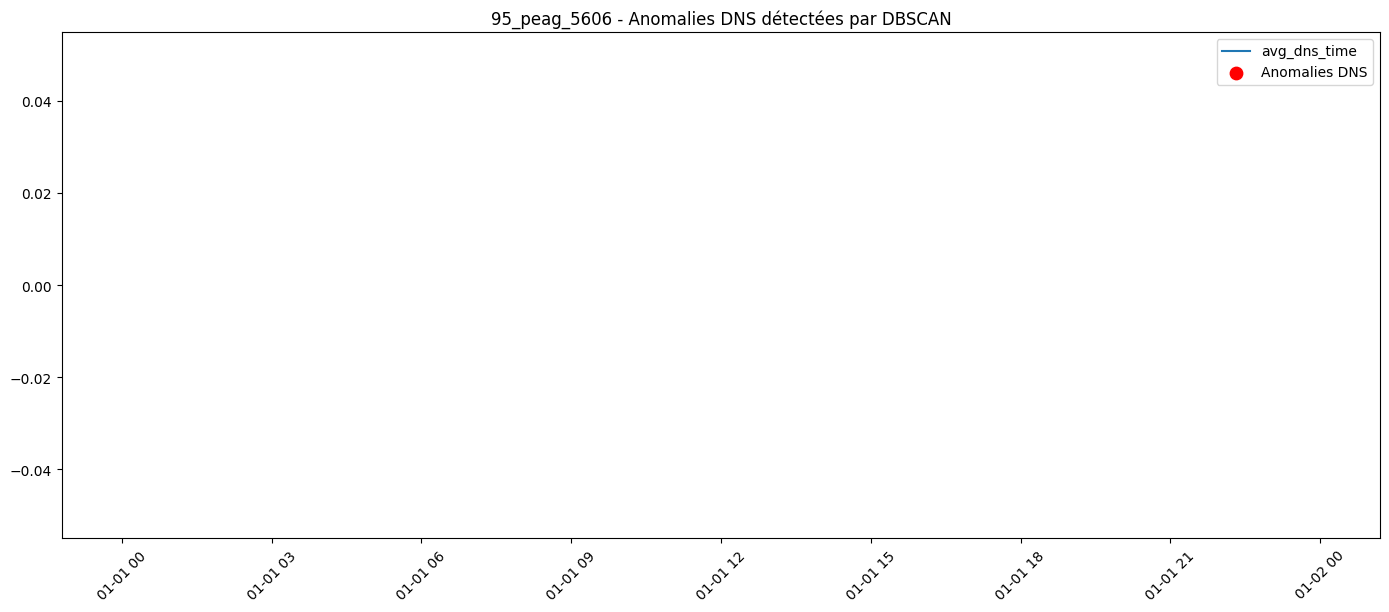

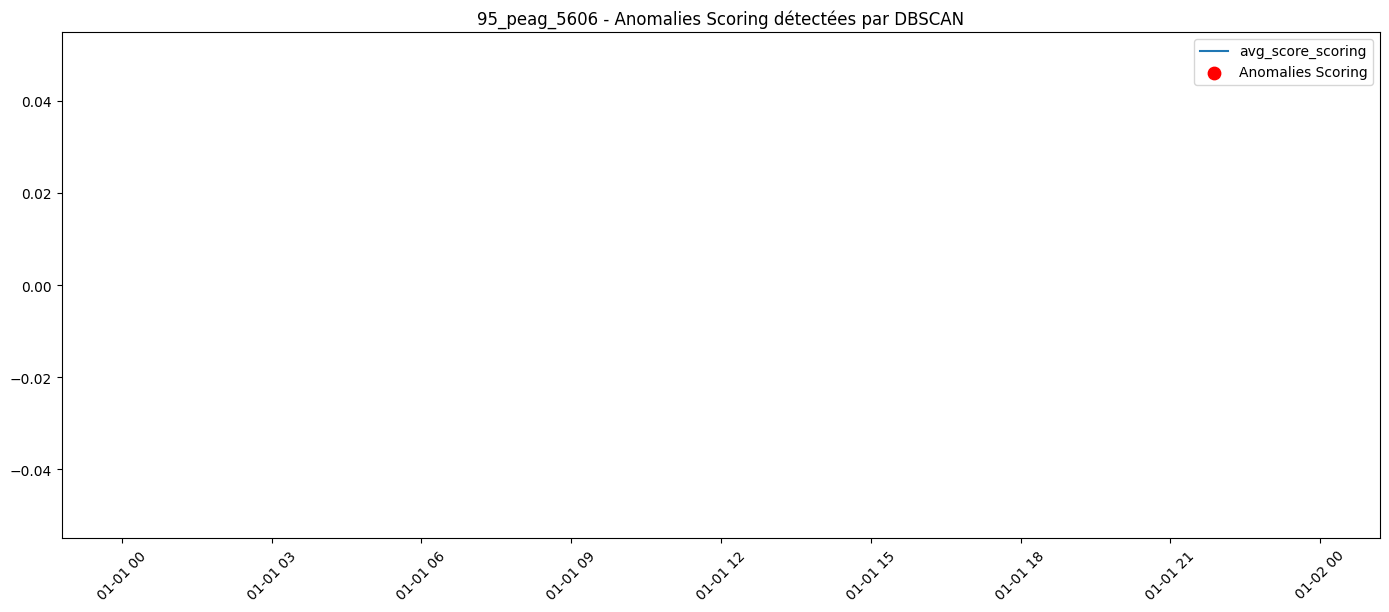

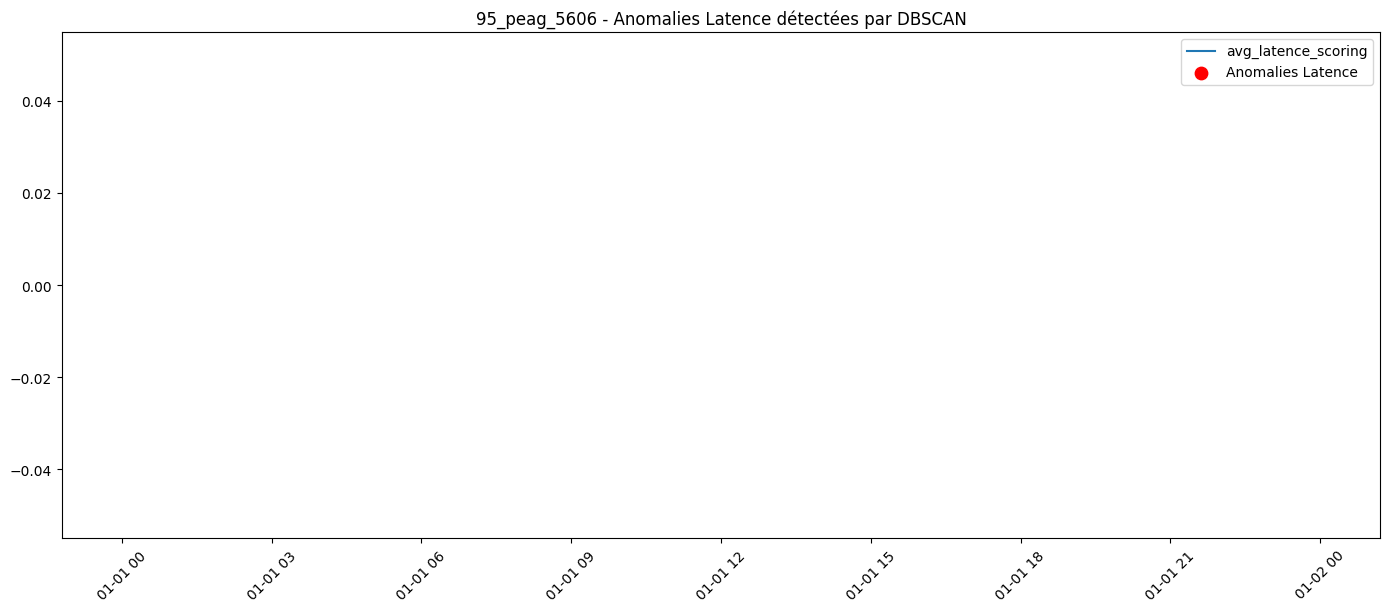

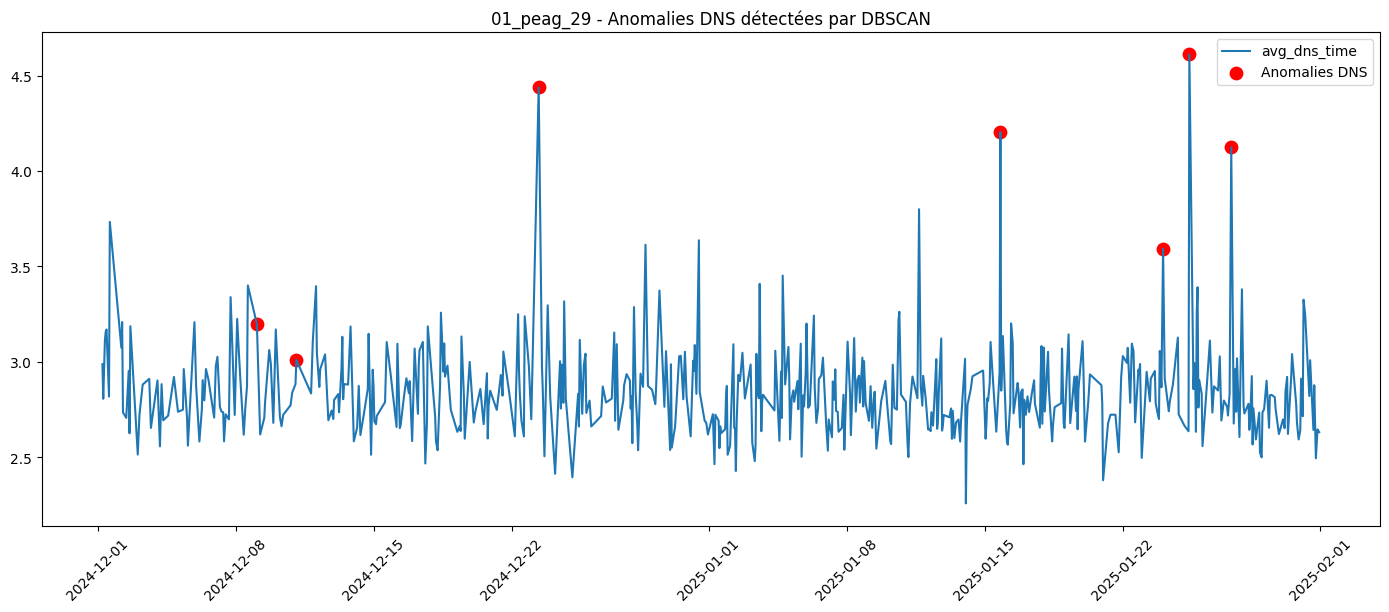

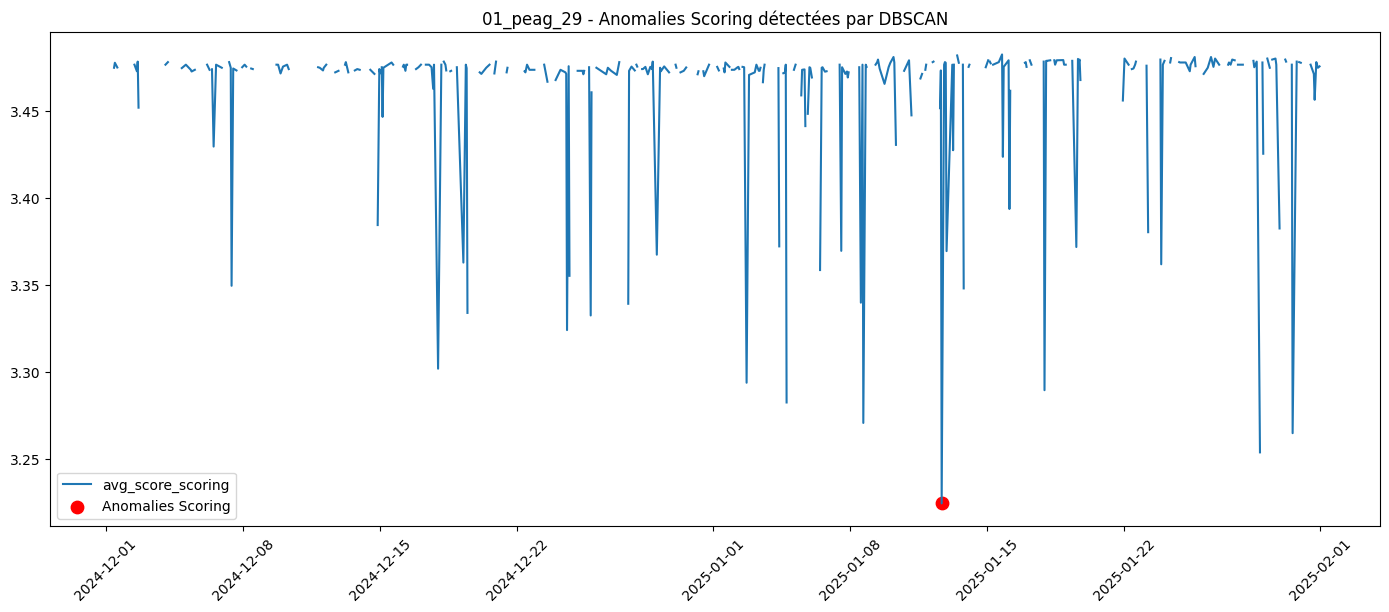

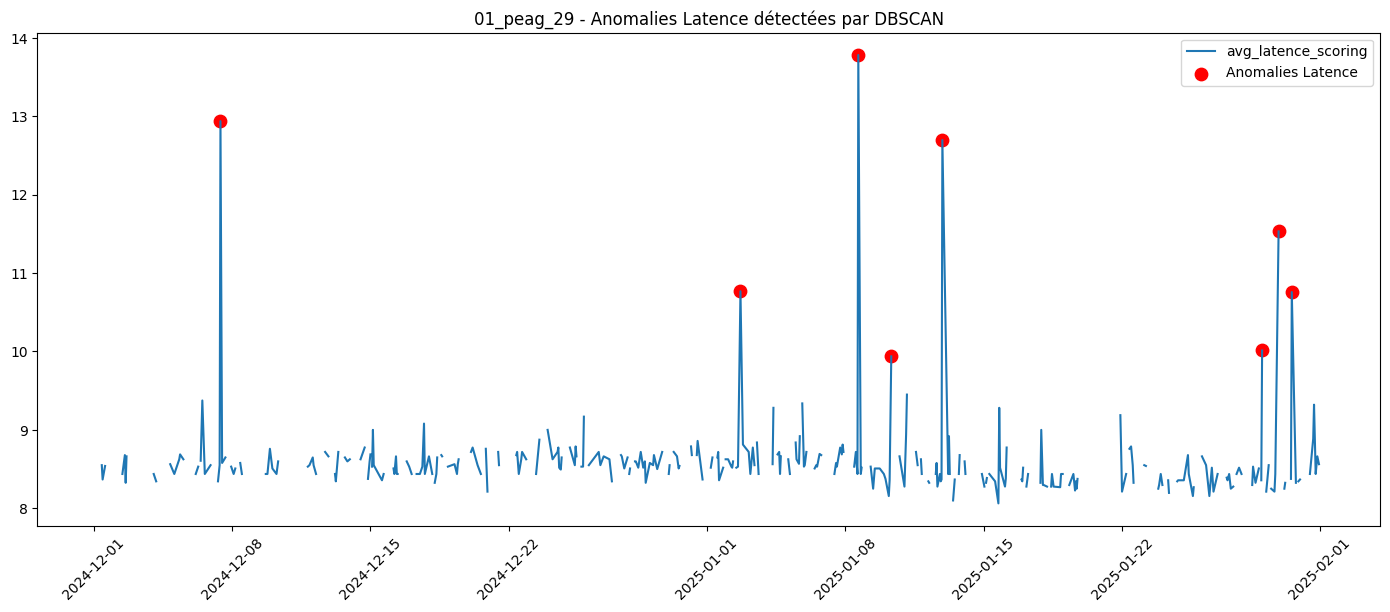

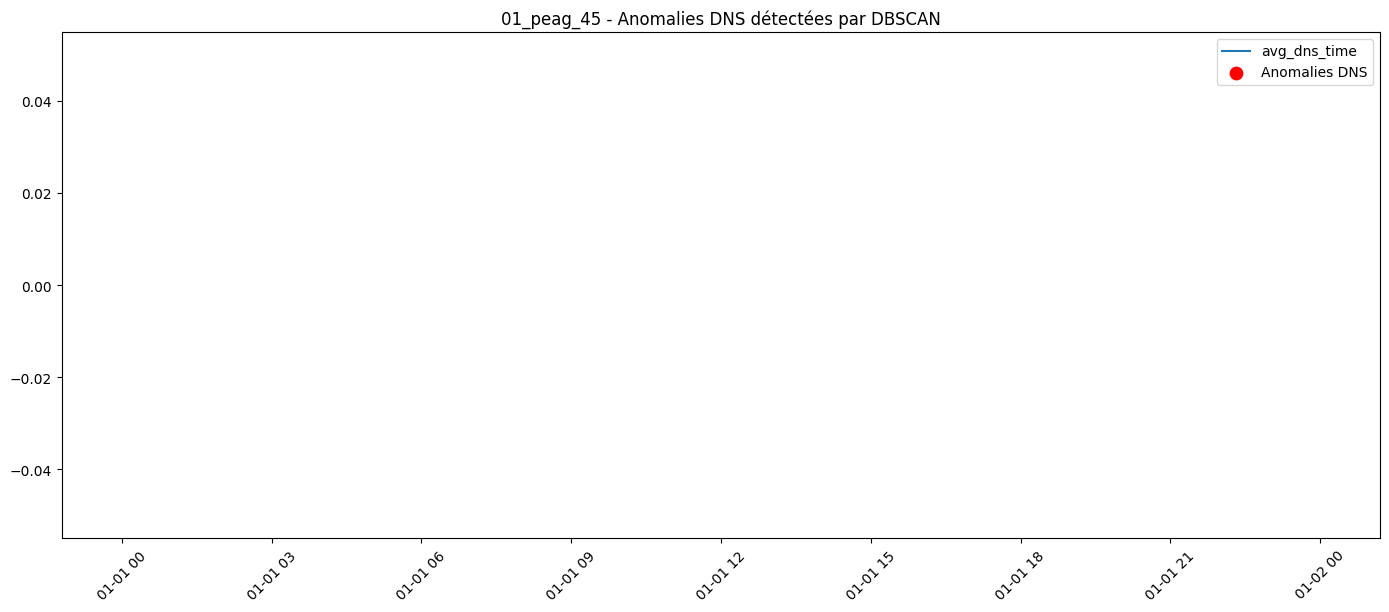

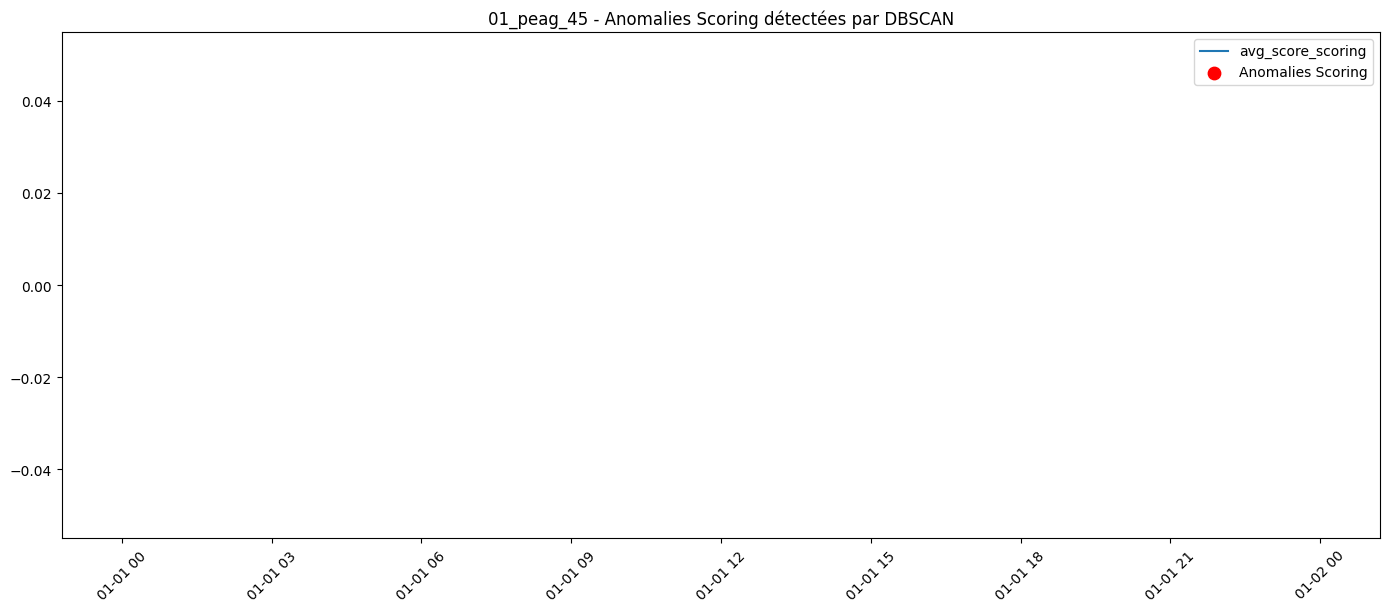

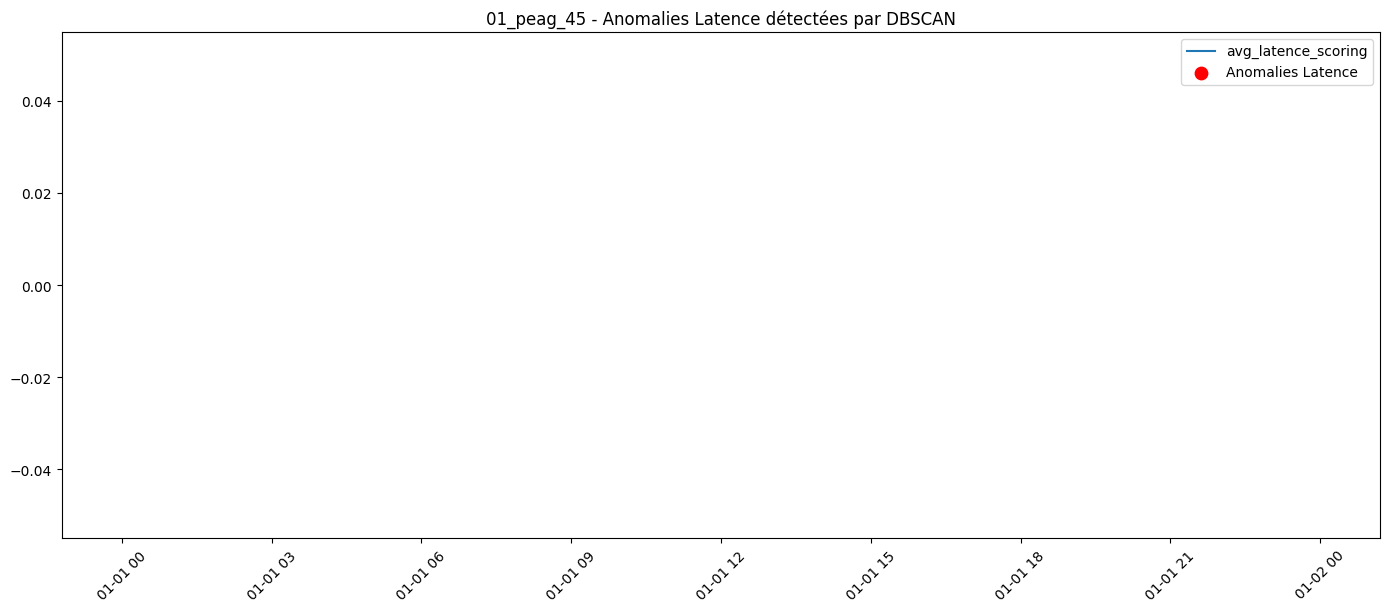

In [13]:
# Visualiser les anomalies pour chaque PEAG
for peag in peags_test:
    df_peag = df_with_anomalies[df_with_anomalies['peag_nro'] == peag]

    # Pour le test DNS
    plt.figure(figsize=(14, 6))
    plt.plot(df_peag['date_hour'], df_peag['avg_dns_time'], label='avg_dns_time')
    plt.scatter(
        df_peag['date_hour'][df_peag['is_anomaly_dns']],
        df_peag['avg_dns_time'][df_peag['is_anomaly_dns']],
        color='red', label='Anomalies DNS', s=80
    )
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.title(f"{peag} - Anomalies DNS détectées par DBSCAN")
    plt.show()

    # Pour le test Scoring
    if 'avg_score_scoring' in df_peag.columns and 'is_anomaly_scoring' in df_peag.columns:
        plt.figure(figsize=(14, 6))
        plt.plot(df_peag['date_hour'], df_peag['avg_score_scoring'], label='avg_score_scoring')
        plt.scatter(
            df_peag['date_hour'][df_peag['is_anomaly_scoring']],
            df_peag['avg_score_scoring'][df_peag['is_anomaly_scoring']],
            color='red', label='Anomalies Scoring', s=80
        )
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.title(f"{peag} - Anomalies Scoring détectées par DBSCAN")
        plt.show()

    # Pour le test Latence
    if 'avg_latence_scoring' in df_peag.columns and 'is_anomaly_latence' in df_peag.columns:
        plt.figure(figsize=(14, 6))
        plt.plot(df_peag['date_hour'], df_peag['avg_latence_scoring'], label='avg_latence_scoring')
        plt.scatter(
            df_peag['date_hour'][df_peag['is_anomaly_latence']],
            df_peag['avg_latence_scoring'][df_peag['is_anomaly_latence']],
            color='red', label='Anomalies Latence', s=80
        )
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.title(f"{peag} - Anomalies Latence détectées par DBSCAN")
        plt.show()

In [14]:
def add_anomaly_flags_silent(base_df, test_types=['dns', 'scoring', 'latence']):
    """
    Ajoute des colonnes binaires d'anomalies au DataFrame de base
    """
    result_df = base_df.copy()

    # Initialiser les colonnes d'anomalies à False
    for test_type in test_types:
        result_df[f'is_anomaly_{test_type}'] = False

    # Pour chaque PEAG
    for peag in base_df['peag_nro'].unique():
        df_peag = base_df[base_df['peag_nro'] == peag]

        for test_type in test_types:
            # Appliquer DBSCAN
            df_anomalies = detect_anomalies_dbscan(df_peag, test_type=test_type, eps=3, min_samples=3)

            if df_anomalies is not None:
                if test_type == 'dns':
                    anomaly_col = 'anomaly_dns'
                elif test_type == 'scoring':
                    anomaly_col = 'anomaly_scoring'
                elif test_type == 'latence':
                    anomaly_col = 'anomaly_latence'

                # Identifier les dates/heures des anomalies
                anomaly_indices = df_anomalies[df_anomalies[anomaly_col] == -1].index
                anomaly_dates = df_anomalies.loc[anomaly_indices, 'date_hour'].tolist()

                # Mettre à jour le DataFrame résultat
                mask = (result_df['peag_nro'] == peag) & (result_df['date_hour'].isin(anomaly_dates))
                result_df.loc[mask, f'is_anomaly_{test_type}'] = True

    return result_df

In [19]:
col = 'is_anomaly_dns'  # ou 'is_anomaly_avg_dns_time' selon ton code

# S'assurer que la colonne 'date_hour' est bien en datetime
df_with_anomalies['date_hour'] = pd.to_datetime(df_with_anomalies['date_hour'])

# Analyse par PEAG
for peag in df_with_anomalies['peag_nro'].unique():
    df_peag = df_with_anomalies[df_with_anomalies['peag_nro'] == peag]

    total_anomalies = df_peag[col].sum()
    total_hours = df_peag['date_hour'].nunique()
    total_days = df_peag['date_hour'].dt.date.nunique()

    anomalies_per_hour = total_anomalies / total_hours if total_hours else 0
    anomalies_per_day = total_anomalies / total_days if total_days else 0

    print(f"🔍 PEAG : {peag}")
    print(f"🔴 Nombre total d'anomalies détectés : {total_anomalies}")
    print(f"⏱️ Nombre d'heures mesurées : {total_hours}")
    print(f"📅 Nombre de jours : {total_days}")
    print(f"📊 Proportion d'anomalies par jour : {anomalies_per_day:.2f}")
    print("-" * 60)

🔍 PEAG : 01_peag_29
🔴 Nombre total d'anomalies détectés : 7
⏱️ Nombre d'heures mesurées : 565
📅 Nombre de jours : 62
📊 Proportion d'anomalies par jour : 0.11
------------------------------------------------------------


In [16]:
data_agrege_with_anomalies = add_anomaly_flags_silent(data_agrege_S3, test_types=['dns', 'scoring', 'latence'])

In [17]:
data_agrege_with_anomalies

,peag_nro,date_hour,code_departement,olt_model,olt_name,boucle,dsp,pop_dns,nb_test_dns,avg_dns_time,...,type_boucle,type_olt_model,encodage_heure_sin,encodage_heure_cos,encodage_jour_semaine_sin,encodage_jour_semaine_cos,week_end,is_anomaly_dns,is_anomaly_scoring,is_anomaly_latence
0,01_peag_1,2024-12-01 00:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,61,4.888439,...,BU,old,0.000000,1.000000,-0.781831,0.623490,True,False,False,False
1,01_peag_1,2024-12-01 01:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,58,5.293034,...,BU,old,0.258819,0.965926,-0.781831,0.623490,True,False,False,False
2,01_peag_1,2024-12-01 02:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,67,5.103739,...,BU,old,0.500000,0.866025,-0.781831,0.623490,True,False,False,False
3,01_peag_1,2024-12-01 03:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,40,5.342719,...,BU,old,0.707107,0.707107,-0.781831,0.623490,True,False,False,False
4,01_peag_1,2024-12-01 04:00:00,01,old0,01_olt_1,BU966,dsp_1,69_lyon,50,4.997415,...,BU,old,0.866025,0.500000,-0.781831,0.623490,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2386830,95_peag_2931,2025-01-31 19:00:00,95,M22,95_olt_5629,BU72,dsp_1,77_mit,14,2.813250,...,BU,New,-0.965926,0.258819,-0.433884,-0.900969,False,False,False,False
2386831,95_peag_2931,2025-01-31 20:00:00,95,M22,95_olt_5629,BU72,dsp_1,77_mit,28,3.253500,...,BU,New,-0.866025,0.500000,-0.433884,-0.900969,False,False,False,False
2386832,95_peag_2931,2025-01-31 21:00:00,95,M22,95_olt_5629,BU72,dsp_1,77_mit,22,3.016670,...,BU,New,-0.707107,0.707107,-0.433884,-0.900969,False,False,False,False
2386833,95_peag_2931,2025-01-31 22:00:00,95,M22,95_olt_5629,BU72,dsp_1,77_mit,15,2.893250,...,BU,New,-0.500000,0.866025,-0.433884,-0.900969,False,False,False,False


In [18]:
output_parquet_path = "/content/drive/MyDrive/nexialog/data_with_anomalies_DBSCAN_model_PEAG.parquet"

# Exporter au format Parquet
data_agrege_with_anomalies.to_parquet(output_parquet_path, index=False, engine='pyarrow')
print(f"Fichier Parquet exporté avec succès à : {output_parquet_path}")

Fichier Parquet exporté avec succès à : /content/drive/MyDrive/nexialog/data_with_anomalies_DBSCAN_model_PEAG.parquet
